In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np


In [5]:
import os 
os.listdir("/kaggle/input/competitions/quora-question-pairs")

['train.csv.zip', 'sample_submission.csv.zip', 'test.csv', 'test.csv.zip']

In [ ]:
!unzip  /kaggle/input/competitions/quora-question-pairs/train.csv.zip

In [6]:
import zipfile

with zipfile.ZipFile("/kaggle/input/competitions/quora-question-pairs/train.csv.zip", "r") as zip_ref:
    zip_ref.extractall("/kaggle/working/")
    

In [7]:
df= pd.read_csv("/kaggle/working/train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [9]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['is_duplicate'].value_counts()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

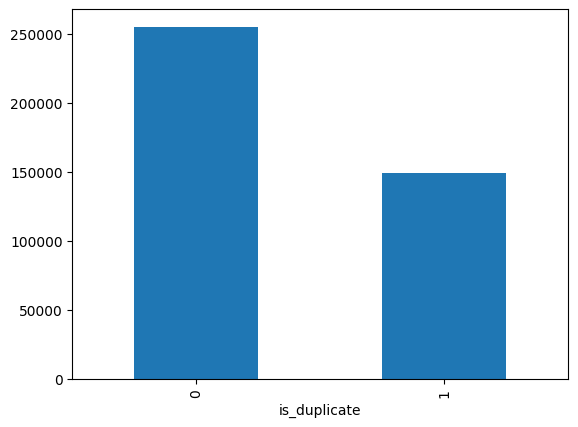

In [12]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [13]:
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique question',np.unique(qid).shape[0])
x = qid.value_counts()>1
print("Number of question getting repeated ,",x[x].shape[0])

Number of unique question 537933
Number of question getting repeated , 111780


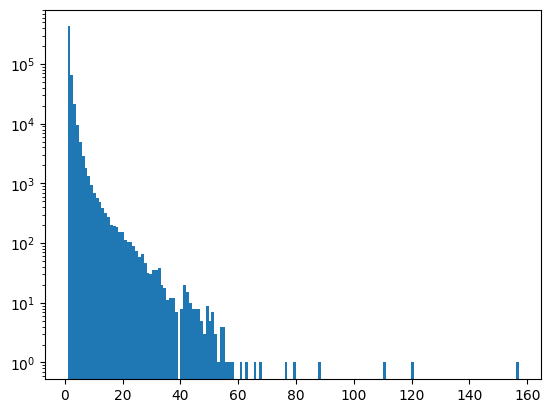

In [14]:
import matplotlib.pyplot as plt

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

# ONLY_RAW DATA __BOW__ 

In [15]:
new_sample_df = df.sample(3000)

In [16]:
new_sample_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [17]:
new_sample_df.duplicated().sum()

np.int64(0)

In [18]:
new_sample_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
18748,18748,18296,35498,Why do some people on QUORA ask questions that...,Do people post questions in Quora just so that...,1
237664,237664,348874,141506,"How is SGSITS, Indore for CSE? What is the ave...",Do all CSE undergrads in the old IITs get plac...,0
161518,161518,251668,251669,Why is Winston Churchill loved?,What was Winston Churchill like?,0
229479,229479,245666,338798,Why are women usually so finicky and complicat...,I am 26years old . Can I start playing Billiar...,0
214580,214580,81058,319349,Why are we afraid of change?,Why are people afraid of Change ?,1


In [19]:
ques_df = new_sample_df[['question1','question2']]

In [20]:
ques_df.head()

,question1,question2
18748,Why do some people on QUORA ask questions that...,Do people post questions in Quora just so that...
237664,"How is SGSITS, Indore for CSE? What is the ave...",Do all CSE undergrads in the old IITs get plac...
161518,Why is Winston Churchill loved?,What was Winston Churchill like?
229479,Why are women usually so finicky and complicat...,I am 26years old . Can I start playing Billiar...
214580,Why are we afraid of change?,Why are people afraid of Change ?


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
questions = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)


In [23]:
cv.get_feature_names_out()

array(['000', '10', '100', ..., 'zero', 'zone', 'zuckerberg'],
      dtype=object)

In [25]:
ques_df.index

Index([ 18748, 237664, 161518, 229479, 214580, 253589, 260322,  80713, 165794,
       384807,
       ...
       241896, 186710, 226119, 265592,  71188,  93919,  58546, 248057, 164529,
       211827],
      dtype='int64', length=3000)

In [27]:
temp_df1 = pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr,index=ques_df.index)

temp_df = pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(3000, 6000)

In [28]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
18748,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
237664,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
161518,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
229479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
214580,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93919,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
58546,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
248057,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
164529,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
temp_df['is_duplicate'] = new_sample_df['is_duplicate']

In [30]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
18748,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
237664,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
161518,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
229479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
214580,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    temp_df.iloc[:,0:-1].values,
    temp_df.iloc[:,-1].values,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducible results
    shuffle=True
)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7166666666666667


In [34]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred_xgb = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_xgb)

print("Accuracy:", accuracy)

Accuracy: 0.6783333333333333


# Feature engineering

In [90]:
fe_df = df.sample(30000,random_state=2)
fe_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [91]:
fe_df['q1_len'] = fe_df['question1'].str.len()
fe_df['q2_len'] = fe_df['question2'].str.len()

In [92]:
fe_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [93]:
fe_df['q1_num_words'] = fe_df['question1'].apply(lambda row:len(row.split(" ")))
fe_df['q2_num_words'] = fe_df['question2'].apply(lambda row:len(row.split(" ")))
fe_df.head()


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [94]:
def common_word(row):
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split(" ")))
    return len(w1&w2)

In [95]:
list(set(map(lambda word:word.lower().strip(), 'What is the best marketing automation tool for..'.split(" "))))

['tool', 'is', 'best', 'marketing', 'for..', 'what', 'automation', 'the']

In [96]:
fe_df['word_common'] = fe_df.apply(common_word,axis=1)
fe_df.head()


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [97]:
def total_words(row):
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split(" ")))
    return len(w1) + len(w2)

In [98]:
fe_df['word_total'] = fe_df.apply(total_words,axis=1)
fe_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [99]:
fe_df['word_share'] = round(fe_df['word_common']/fe_df['word_total'],2)
fe_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


In [100]:
len(fe_df['word_share'].unique())

50

minimum characters  2
max characters  391
avg characters  59


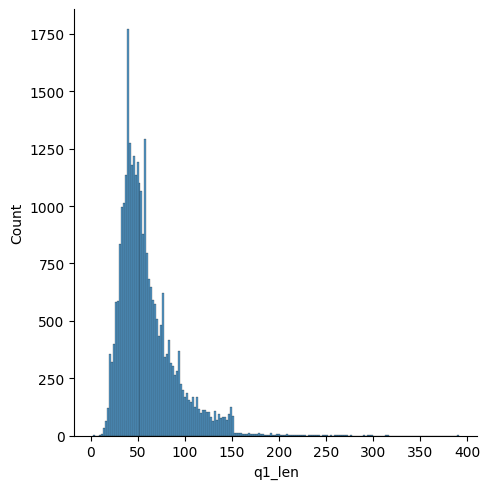

In [101]:
import seaborn as sns
sns.displot(fe_df['q1_len'])
print('minimum characters ', fe_df['q1_len'].min())
print('max characters ', fe_df['q1_len'].max())
print('avg characters ', int(fe_df['q1_len'].mean()))

minimum characters  6
max characters  1151
avg characters  60


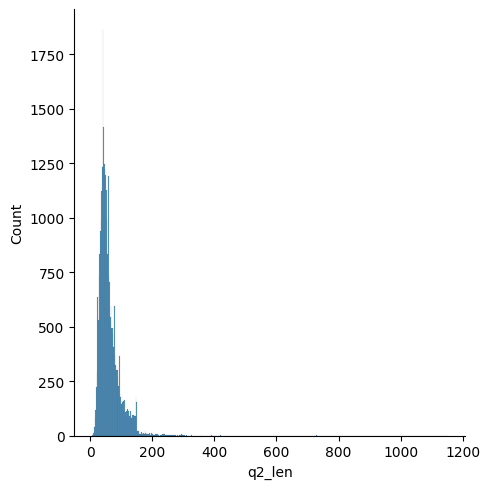

In [102]:
import seaborn as sns
sns.displot(fe_df['q2_len'])
print('minimum characters ', fe_df['q2_len'].min())
print('max characters ', fe_df['q2_len'].max())
print('avg characters ', int(fe_df['q2_len'].mean()))

/tmp/ipykernel_77/796558027.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_df[fe_df['is_duplicate']==0]['word_common'],label='non duplicate')
/tmp/ipykernel_77/796558027.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_df[fe_df['is_duplicate']==1]['word_common'],label='duplicate')


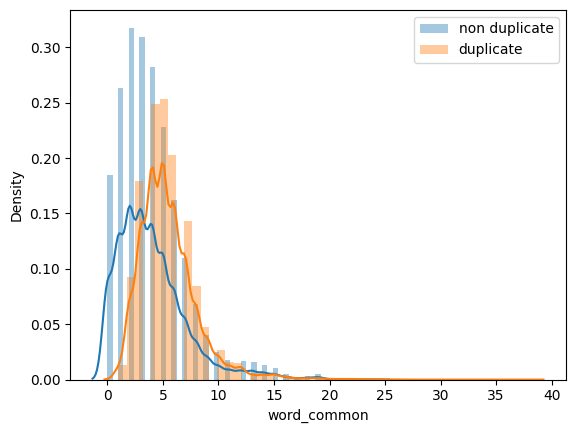

In [103]:
sns.distplot(fe_df[fe_df['is_duplicate']==0]['word_common'],label='non duplicate')
sns.distplot(fe_df[fe_df['is_duplicate']==1]['word_common'],label='duplicate')
plt.legend()
plt.show()

/tmp/ipykernel_77/3042298296.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_df[fe_df['is_duplicate']==0]['word_share'],label='non duplicate')
/tmp/ipykernel_77/3042298296.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_df[fe_df['is_duplicate']==1]['word_share'],label='duplicate')


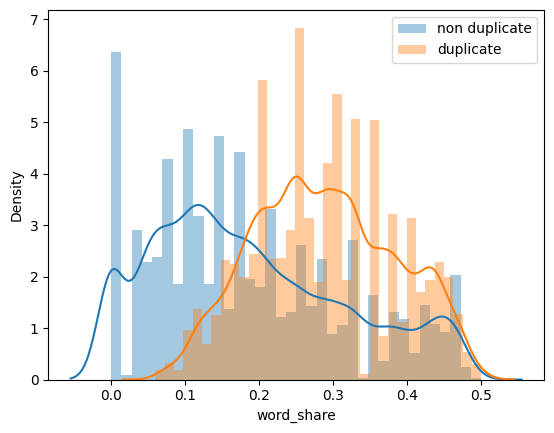

In [104]:
sns.distplot(fe_df[fe_df['is_duplicate']==0]['word_share'],label='non duplicate')
sns.distplot(fe_df[fe_df['is_duplicate']==1]['word_share'],label='duplicate')
plt.legend()
plt.show()

/tmp/ipykernel_77/4281186282.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_df[fe_df['is_duplicate']==0]['word_total'],label='non duplicate')
/tmp/ipykernel_77/4281186282.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_df[fe_df['is_duplicate']==1]['word_total'],label='duplicate')


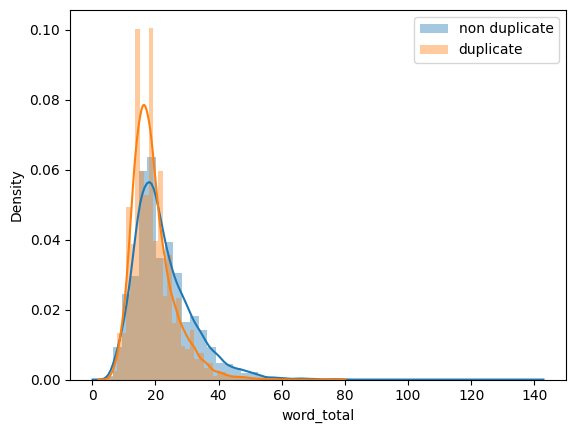

In [105]:
sns.distplot(fe_df[fe_df['is_duplicate']==0]['word_total'],label='non duplicate')
sns.distplot(fe_df[fe_df['is_duplicate']==1]['word_total'],label='duplicate')
plt.legend()
plt.show()

In [106]:
final_df = fe_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


In [107]:
questions = (
    fe_df['question1'].fillna('').tolist() +
    fe_df['question2'].fillna('').tolist()
)
cv_q = CountVectorizer(max_features=3000)
q1_arr , q2_arr = np.vsplit(cv_q.fit_transform(questions).toarray(),2)

In [109]:
temp_df1 = pd.DataFrame(q1_arr,index=fe_df.index)
temp_df2 = pd.DataFrame(q2_arr,index=fe_df.index)

temp_df = pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [110]:
final_df = pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [111]:
print("fe_df:", fe_df.shape)
print("ques_df:", ques_df.shape)
print("q1_arr:", q1_arr.shape)
print("q2_arr:", q2_arr.shape)

fe_df: (30000, 13)
ques_df: (3000, 2)
q1_arr: (30000, 3000)
q2_arr: (30000, 3000)


In [112]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [ ]:
from sklearn.model_selection import train_test_split

In [113]:
X = final_df.drop(columns=['is_duplicate'])
y = final_df['is_duplicate']

In [118]:
str_cols = [col for col in X.columns if isinstance(col, str)]
print(str_cols)

['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common', 'word_total', 'word_share']


In [121]:
X.columns = X.columns.astype(str)

In [122]:
print(X.shape)
print(y.shape)

(30000, 6007)
(30000,)


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    shuffle=True
)

In [124]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7653333333333333
